# Questions analysis
This notebook is to analyze the annotated questions

In [1]:
import json
import matplotlib.pyplot as plt

In [2]:
input_folder = "../dataset_final"

with open(f"{input_folder}/questions_cosmos-drive-dreams.json") as f:
    questions_dd_raw = json.load(f)

with open(f"{input_folder}/questions_cosmos-predict1.json") as f:
    questions_p1_raw = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: './dataset_final/questions_cosmos-drive-dreams.json'

In [36]:
def num_rm_videos(questions_list):
    tot_rm = 0
    questions_cleaned = []
    for question in questions_list:
        if 'remove' in question.keys():
            tot_rm +=1
        else:
            questions_cleaned.append(question)
    return tot_rm, questions_cleaned

rm_q_dd, questions_dd = num_rm_videos(questions_dd_raw)
rm_q_p1, questions_p1 = num_rm_videos(questions_p1_raw)

tot_videos = len(questions_p1_raw) + len(questions_dd_raw)
tot_usable_videos = tot_videos - rm_q_dd - rm_q_p1

#######
print(f"There are {tot_videos} videos from which {tot_usable_videos} are usable.")
print(f"It means that {tot_usable_videos/tot_videos*100:0.1f}% is the ratio of usable videos.")
print(f"{len(questions_dd)/tot_usable_videos*100:0.1f}% of the videos are coming from cosmos-drive-dreams.")
print(f"{len(questions_p1)/tot_usable_videos*100:0.1f}% of the videos are coming from cosmos-predict1.")

There are 2371 videos from which 1598 are usable.
It means that 67.4% is the ratio of usable videos.
69.0% of the videos are coming from cosmos-drive-dreams.
31.0% of the videos are coming from cosmos-predict1.


In [39]:
def num_questions(questions_list):
    num_q = 0
    for question in questions_list:
        num_q += len(question["qa_pairs"])
    return num_q

num_q_dd = num_questions(questions_dd)
num_q_p1 = num_questions(questions_p1)
num_q_tot = num_q_dd + num_q_p1

####
print(f"There are {num_q_tot} questions in total.")
print(f"{num_q_dd/num_q_tot*100:0.1f}% of the questions are coming from cosmos-drive-dreams.")
print(f"{num_q_p1/num_q_tot*100:0.1f}% of the questions are coming from cosmos-predict1.")

There are 7375 questions in total.
76.7% of the questions are coming from cosmos-drive-dreams.
23.3% of the questions are coming from cosmos-predict1.


In [49]:
def get_questions_categories(questions_list):
    categories = []
    for el in questions_list:
        for question in el["qa_pairs"]:
            if question["category"] not in categories:
                categories.append(question["category"])
    return categories

categories_p1 = get_questions_categories(questions_p1)
categories_dd = get_questions_categories(questions_dd)
categories = list(set(categories_p1).union(set(categories_dd)))

#####
print(f"The categories are : \n")
for category in categories:
    print(f"- {category}")

The categories are : 

- Artifacts understanding
- Traffic laws understanding
- Visual understanding
- Reality understanding
- Safety understanding
- Spatial-temporal understanding


In [56]:
def get_num_questions_per_category(questions_list, categories = categories):
    questions_per_cat = {category : 0 for category in categories}
    for el in questions_list:
        for question in el["qa_pairs"]:
            category = question["category"]
            questions_per_cat[category] +=1
    return questions_per_cat

questions_per_cat_dd = get_num_questions_per_category(questions_dd)
questions_per_cat_p1 = get_num_questions_per_category(questions_p1)

questions_per_cat = {key: questions_per_cat_dd[key] + questions_per_cat_p1[key] 
                     for key in questions_per_cat_p1}

#####
print(f"The number of questions per category are : \n")
for category, num_q in questions_per_cat.items():
    print(f"- {category} : {num_q}")

The number of questions per category are : 

- Artifacts understanding : 729
- Traffic laws understanding : 665
- Visual understanding : 304
- Reality understanding : 3174
- Safety understanding : 2164
- Spatial-temporal understanding : 339


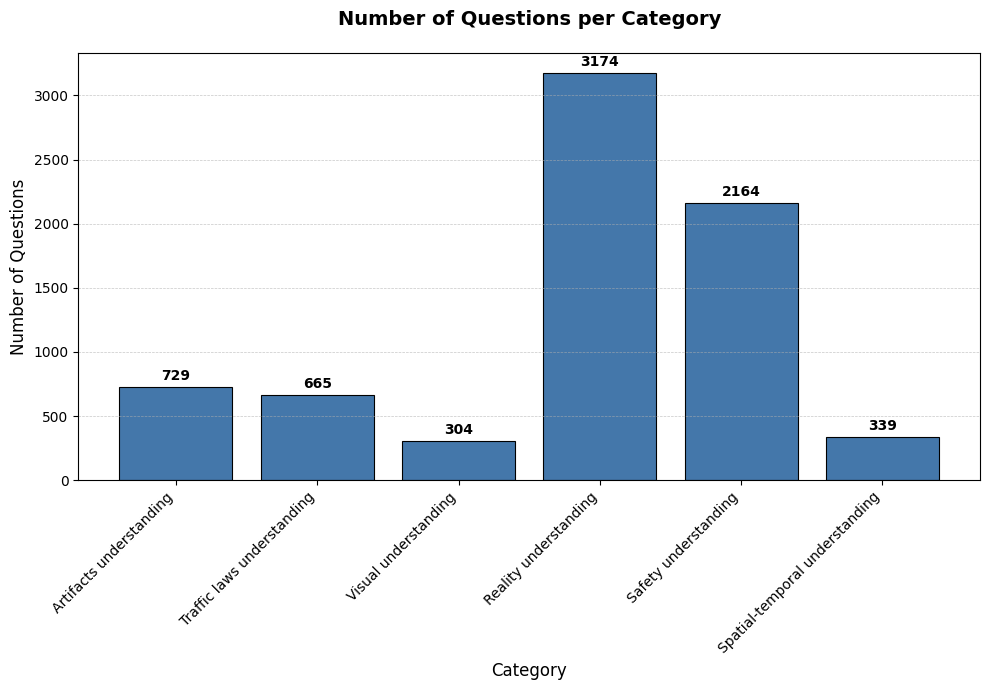

In [60]:
# Extract data
categories = list(questions_per_cat.keys())
counts = list(questions_per_cat.values())

# Create the bar plot
plt.figure(figsize=(10, 7))  # Adjust size as needed
plt.bar(categories, counts, color='#4477AA', edgecolor='black', linewidth=0.8)

# Beautify the plot
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Questions', fontsize=12)
plt.title('Number of Questions per Category', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate labels if they are long
plt.grid(axis='y', linestyle='--', alpha=0.7, linewidth=0.5)

# Optional: display count on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, str(count), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [63]:
def get_num_videos_per_category(questions_list, categories = categories):
    videos_per_cat = {category : 0 for category in categories}
    for el in questions_list:
        current_cat = []
        for question in el["qa_pairs"]:
            category = question["category"]
            if category not in current_cat:
                current_cat.append(category)
                videos_per_cat[category] +=1
    return videos_per_cat

videos_per_cat_dd = get_num_videos_per_category(questions_dd)
videos_per_cat_p1 = get_num_videos_per_category(questions_p1)

videos_per_cat = {key: videos_per_cat_dd[key] + videos_per_cat_p1[key] 
                     for key in videos_per_cat_p1}

#####
print(f"The number of videos per category are : \n")
for category, num_v in videos_per_cat.items():
    print(f"- {category} : {num_v}")

The number of videos per category are : 

- Artifacts understanding : 448
- Traffic laws understanding : 515
- Visual understanding : 304
- Reality understanding : 1598
- Safety understanding : 1082
- Spatial-temporal understanding : 339


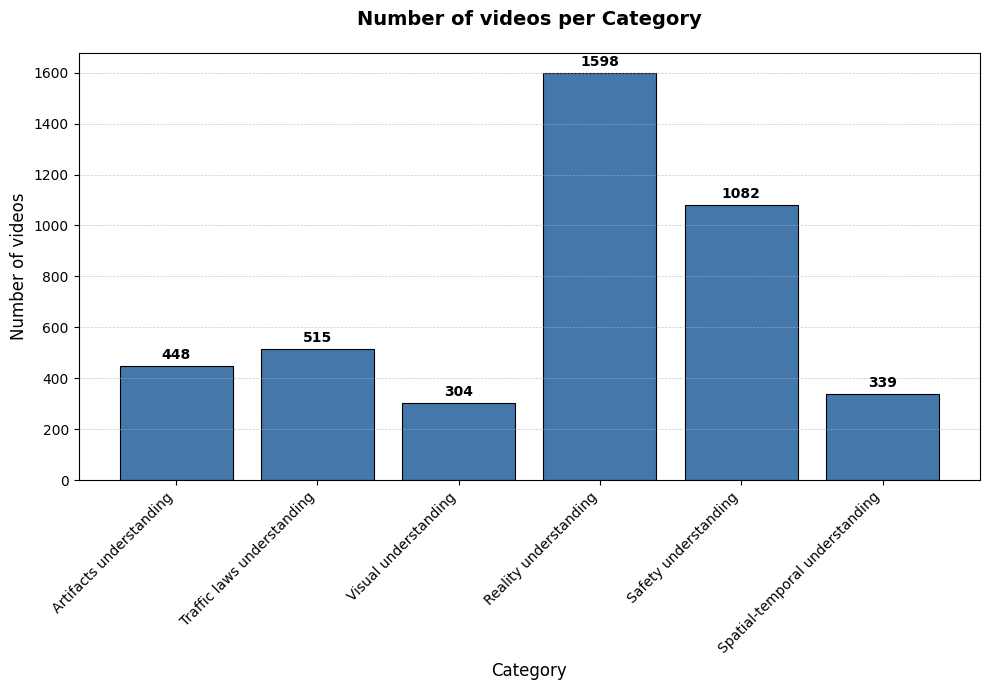

In [64]:
# Extract data
categories = list(videos_per_cat.keys())
counts = list(videos_per_cat.values())

# Create the bar plot
plt.figure(figsize=(10, 7))  # Adjust size as needed
plt.bar(categories, counts, color='#4477AA', edgecolor='black', linewidth=0.8)

# Beautify the plot
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of videos', fontsize=12)
plt.title('Number of videos per Category', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate labels if they are long
plt.grid(axis='y', linestyle='--', alpha=0.7, linewidth=0.5)

# Optional: display count on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, str(count), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()